classification binaire de base
    Créer un dataset (toutes les images livrable 1)
    Load un modèle préentrainé


Récupérer les index des photos du dataset


Effectuer le denoizing sur le dataset prédit



Tensor("args_0:0", shape=(), dtype=string)
b'/tf/projet/Dataset/Dataset Livrable 1/Test/test.png'
(180, 180, 3)


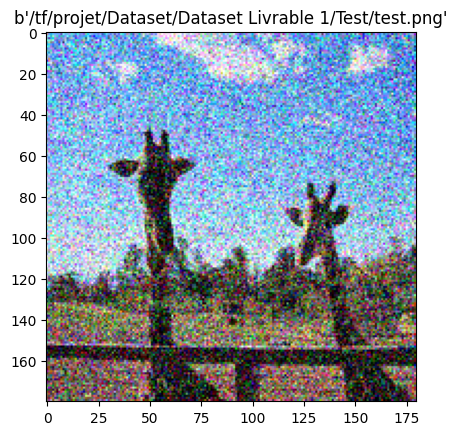

In [129]:
import tensorflow as tf
import os
import glob
import matplotlib.pyplot as plt
import math


FOLDERS = ["/tf/projet/Dataset/Dataset Livrable 1/Test"]
CLASSIF_MODEL_PATH = "/tf/projet/Leyanda_Project/models/saved/Leyanda_CNN_bin_Photo_transfer_e10_b64_class_weight.keras"
DENOISER_MODEL_PATH = "/tf/projet/Leyanda_Project/models/saved/denoiser.keras"
CAPTION_MODEL_PATH = "/tf/projet/Leyanda_Project/models/saved/caption_model.keras"
TOKENIZER_PATH = "/tf/projet/Leyanda_Project/models/saved/tokenizer.pkl"
DENOISED_OUTPUT_DIR = "/tf/projet/Dataset/Dataset_Filtered_Denoised"

img_height = 180
img_width  = 180
BATCH_SIZE = 64

# Lister toutes les images
image_paths = []
for folder in FOLDERS:
    image_paths.extend(glob.glob(os.path.join(folder, "*.[jp][pn]g")))

def load_and_preprocess(path):
    image = tf.io.read_file(path)
    print(path)
    image = tf.image.decode_image(image, channels=3)
    image.set_shape([180, 180, 3])  # Explicitly set the shape
    image = tf.image.resize(image, [180, 180])  # À adapter à ton modèle
    image = tf.cast(image, tf.float32)
    return image, path

dataset = tf.data.Dataset.from_tensor_slices(image_paths)
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(buffer_size=math.ceil(len(image_paths)/4))


# show first elements of dataset
for image, path in dataset.take(1):
    image = image / 255.0
    print(path.numpy())
    print(image.numpy().shape)
    plt.imshow(image.numpy())
    plt.title(path.numpy())
    plt.show()


In [127]:
# Chargement du modèle de classification
model_classif = tf.keras.models.load_model("/tf/projet/Leyanda_Project/models/saved/Leyanda_CNN_bin_Photo_transfer_e10_b64_class_weight.keras")

# On batch le dataset
batched_dataset = dataset.batch(BATCH_SIZE)

photo_images_paths = []

for batch_images, batch_paths in batched_dataset:
    predictions = model_classif.predict(batch_images)  # shape (batch_size, 1)
    for i, prob in enumerate(predictions):
        if prob[0] > 0.5:
            photo_images_paths.append(batch_paths[i].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step


In [130]:
import os
import tensorflow as tf

# → Vider (ou créer) le dossier de sortie
if not os.path.exists(DENOISED_OUTPUT_DIR):
    os.makedirs(DENOISED_OUTPUT_DIR)
else:
    for f in os.listdir(DENOISED_OUTPUT_DIR):
        os.remove(os.path.join(DENOISED_OUTPUT_DIR, f))

# 0. Chargement du modèle de débruitage
denoiser = tf.keras.models.load_model(DENOISER_MODEL_PATH)

# 2. Collecte de tous les chemins d’images
file_paths = []
for folder in FOLDERS:
    for f in os.listdir(folder):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            file_paths.append(os.path.join(folder, f))
print(f"Total images à débruiter : {len(file_paths)}")

# 3. Pipeline tf.data pour chargement + prétraitement
def load_and_preprocess(path):
    raw = tf.io.read_file(path)
    # Choix du décodeur selon l’extension
    if tf.strings.regex_full_match(path, r".*\.(jpg|jpeg)$"):
        img = tf.image.decode_jpeg(raw, channels=3)
    else:
        img = tf.image.decode_png(raw, channels=3)
    img = tf.image.resize(img, [img_height, img_width])
    img = tf.cast(img, tf.float32) / 255.0
    return img, path

dataset = (
    tf.data.Dataset.from_tensor_slices(file_paths)
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# 4. Boucle d’inférence par batch et sauvegarde
for batch_imgs, batch_paths in dataset:
    decoded_batch = denoiser.predict(batch_imgs, verbose=0)
    decoded_batch = tf.clip_by_value(decoded_batch, 0.0, 1.0)
    decoded_uint8 = tf.cast(decoded_batch * 255.0, tf.uint8)

    for img_tensor, path_tensor in zip(decoded_uint8, batch_paths):
        filename = os.path.basename(path_tensor.numpy().decode("utf-8"))
        out_path = os.path.join(DENOISED_OUTPUT_DIR, filename)
        # Sauvegarde au format JPEG ou PNG
        if filename.lower().endswith((".jpg", ".jpeg")):
            encoded = tf.image.encode_jpeg(img_tensor, quality=100)
        else:
            encoded = tf.image.encode_png(img_tensor)
        tf.io.write_file(out_path, encoded)
        print(f"[OK] {filename} → {out_path}")


Total images à débruiter : 1
[OK] test.png → /tf/projet/Dataset/Dataset_Filtered_Denoised/test.png


In [131]:
# Re-créer un dataset avec uniquement les images "photo"
photo_dataset = tf.data.Dataset.from_tensor_slices(photo_images_paths)
photo_dataset = photo_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Chargement du modèle de débruitage (autoencodeur)
denoiser = tf.keras.models.load_model(DENOISER_MODEL_PATH)

#empty the /tf/projet/Dataset_Filtered_Denoised directory
if not os.path.exists(DENOISED_OUTPUT_DIR):
    os.makedirs(DENOISED_OUTPUT_DIR)
else:
    for f in os.listdir(DENOISED_OUTPUT_DIR):
        os.remove(os.path.join(DENOISED_OUTPUT_DIR, f))

# Application du dénoising
for image, path in photo_dataset:
    image_batch = tf.expand_dims(image, axis=0)
    denoised_image = denoiser.predict(image_batch)
    
    # save denoised_image in file
    denoised_image = denoised_image / 255.0
    denoised_image = tf.squeeze(denoised_image, axis=0)
    denoised_image = tf.clip_by_value(denoised_image, 0.0, 1.0)

    image = image / 255.0
    image = tf.clip_by_value(image, 0.0, 1.0)
    # resize image to 180x180
    image = tf.image.resize(image, [180, 180])

    denoised_image = tf.image.convert_image_dtype(denoised_image, dtype=tf.uint8)
    denoised_image = tf.image.encode_jpeg(denoised_image)
    denoised_image_path = os.path.join(DENOISED_OUTPUT_DIR, os.path.basename(path.numpy().decode('utf-8')))
    tf.io.write_file(denoised_image_path, denoised_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step


Légende générée : a man is riding a snowboard


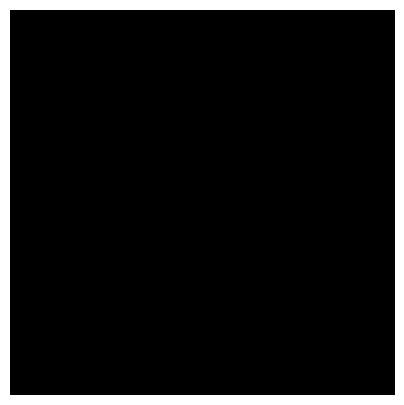

In [132]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

for i in range(1):
    # Chemin de l'image à tester
    first_image = sorted(os.listdir(DENOISED_OUTPUT_DIR))[i]
    image_path = os.path.join(DENOISED_OUTPUT_DIR, first_image)

    # Chargement de l'image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [180, 180])  # Taille à adapter selon ton modèle
    image = tf.keras.applications.inception_v3.preprocess_input(image)  # Exemple avec Inception
    image = tf.expand_dims(image, axis=0)  # Batch dimension

    def generate_caption(model, image, tokenizer, max_length):
        # Récupérer l'ID du token <start>
        start_id = tokenizer.word_index['<start>']
        sequence = [start_id]
        caption = []

        for _ in range(max_length):
            seq_padded = pad_sequences([sequence], maxlen=max_length, padding='post')
            yhat = model.predict([image, seq_padded], verbose=0)
            # On se place sur le pas de temps correspondant à la longueur actuelle
            yhat_id = np.argmax(yhat[0, len(sequence)-1])
            word = tokenizer.index_word.get(yhat_id)
            if word is None or word == '<end>':
                break
            caption.append(word)
            sequence.append(yhat_id)

        return ' '.join(caption)

    # Exemple d’utilisation
    max_caption_len = 20  # À ajuster selon votre modèle
    legend = generate_caption(caption_model, image, tokenizer, max_caption_len)
    print("Légende générée :", legend)


    raw = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [180, 180])
    plt.figure(figsize=(5,5))
    plt.imshow(img.numpy().astype('uint8'))
    plt.axis('off')
    plt.show()
